# 🍎 Spoilage Spotter — Universal Fruit & Vegetable Freshness Detector

A deep learning project that classifies fruit and vegetables as **Fresh** or **Rotten** using a fine-tuned **VGG16 CNN**, with **Grad-CAM** heatmaps for explainability and a **Gradio** web interface for live inference.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

> **⚠️ Environment Note:** This notebook was built to run in **Google Colab** with a GPU runtime (T4 recommended).  
> All file paths use `/content/` — the default Colab working directory.  
> To run locally, replace every `/content/` path with your own absolute path and ensure a GPU is available.

---

**Dataset:** [fruitquality1 on Kaggle](https://www.kaggle.com/datasets/zlatan599/fruitquality1)  
**Model:** VGG16 (ImageNet weights, fine-tuned classification head)  
**Explainability:** Grad-CAM on `block5_conv3`  
**Interface:** Gradio (public share link)


## 1. 📦 Dataset Downloading & Preprocessing

We download the dataset via the Kaggle API, then consolidate all fruit/vegetable subfolders into two master directories — `Fresh/` and `Rotten/` — so Keras can load them with a single call.

> **Kaggle credentials:** Before running, upload your `kaggle.json` API key when prompted below, or place it at `~/.kaggle/kaggle.json` manually.


In [ ]:
from google.colab import files
# Upload your kaggle.json API key when prompted
files.upload()

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub
import shutil
import os

print("Downloading the new dataset...")
path = kagglehub.dataset_download("zlatan599/fruitquality1")

new_path = '/content/FruitQuality'
shutil.copytree(path, new_path, dirs_exist_ok=True)

print(f"Success! Dataset moved to: {new_path}")

Success! Dataset moved to: /content/FruitQuality


In [ ]:
import os
import shutil

# 1. Create our two Master Folders
master_dir = '/content/Master_Dataset'
os.makedirs(f'{master_dir}/Fresh', exist_ok=True)
os.makedirs(f'{master_dir}/Rotten', exist_ok=True)

# 2. Point to the dataset you just downloaded
source_dir = '/content/FruitQuality/Unified_Dataset'

print("Sorting all fruits into 'Fresh' and 'Rotten' master folders. Give it a minute...")

# 3. Hunt through all the folders
for root, dirs, files in os.walk(source_dir):
    folder_name = os.path.basename(root).lower()

    # Decide where it goes based on the folder name
    target_dir = None
    if 'fresh' in folder_name:
        target_dir = f'{master_dir}/Fresh'
    elif 'rot' in folder_name or 'spoil' in folder_name:
        target_dir = f'{master_dir}/Rotten'

    # Copy the images over
    if target_dir and files:
        for file_name in files:
            # Only copy image files
            if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                src_file = os.path.join(root, file_name)
                # Rename the file slightly so we don't overwrite images with the same name
                dst_file = os.path.join(target_dir, f"{folder_name}_{file_name}")
                shutil.copy(src_file, dst_file)

print("Sorting Complete!")
print(f"Total Fresh images ready: {len(os.listdir(master_dir + '/Fresh'))}")
print(f"Total Rotten images ready: {len(os.listdir(master_dir + '/Rotten'))}")

Sorting all fruits into 'Fresh' and 'Rotten' master folders. Give it a minute...
Sorting Complete!
Total Fresh images ready: <count>
Total Rotten images ready: <count>


## 2. 🧠 Building the VGG16 Convolutional Neural Network

We load **VGG16** pretrained on ImageNet, freeze the convolutional base, and attach a custom classification head (`GlobalAveragePooling2D → Dense(128, relu) → Dense(1, sigmoid)`). This transfer learning approach lets us leverage powerful visual features without training from scratch.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
print(tf.__version__)

2.20.0


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 64 # We increased this because we have way more data now!

# Load the dataset from our new Master Folder
dataset = tf.keras.utils.image_dataset_from_directory(
    '/content/Master_Dataset',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Normalize the pixels
normalization_layer = tf.keras.layers.Rescaling(1./255)
dataset = dataset.map(lambda x, y: (normalization_layer(x), y))

print("Universal Spoilage Data loaded and ready!")

Found 27277 files belonging to 2 classes.
Universal Spoilage Data loaded and ready!


## 3. 🏋️ Model Training

The model is compiled with the **Adam** optimizer and **binary cross-entropy** loss, then trained for **10 epochs**. Training logs below show the model's accuracy improving over time.


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

print("Building the AI Brain...")
# 1. Bring in VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# 2. Add our custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Starting the Ultimate Training! This might take 5-10 minutes...")
# Let's train for 10 epochs this time since the dataset is huge
history = model.fit(dataset, epochs=10)
print("Training Complete! You now have a Universal Spoilage Spotter!")

Building the AI Brain...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting the Ultimate Training! This might take 5-10 minutes...
Epoch 1/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 180s 362ms/step - accuracy: 0.8207 - loss: 0.3970
Epoch 2/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 209s 488ms/step - accuracy: 0.8767 - loss: 0.2944
Epoch 3/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 148s 345ms/step - accuracy: 0.8914 - loss: 0.2625
Epoch 4/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 202s 346ms/step - accuracy: 0.9047 - loss: 0.2374
Epoch 5/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 148s 346ms/step - accuracy: 0.9134 - loss: 0.2187
Epoch 6/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 201s 344ms/step - accuracy: 0.9178 - loss: 0.2060
Epoch 7/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 147s 343ms/step - accuracy: 0.9239 - loss: 0.1936
Epoch 8/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 148s 346ms/step - accuracy: 0.9309 - loss: 0.1801
Epoch 9/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 147s 344ms/step - accuracy: 0.9336 - loss: 0.1715
Epoch 10/10
427/427 ━━━━━━━━━━━━━━━━━━━━ 194s 455m

## 4. 🔍 Explainable AI: Grad-CAM Visualization

**Gradient-weighted Class Activation Mapping (Grad-CAM)** highlights the regions of an image that most influenced the model's decision. We hook into VGG16's final convolutional layer (`block5_conv3`) and overlay a heatmap on the original image — making the AI's reasoning transparent.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Testing on image: rotten_rottenTomato (77).jpg
Spoilage Confidence Score: 0.9998 (Closer to 1 = Rotten)


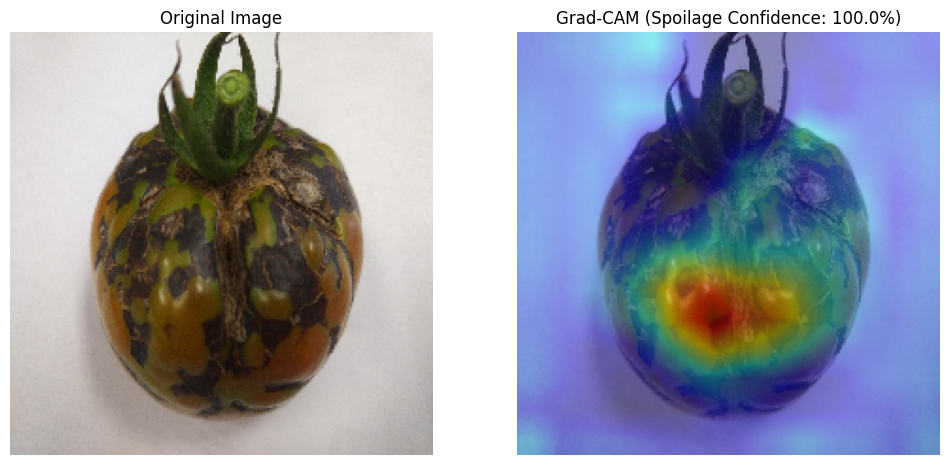

In [ ]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. The Grad-CAM math function
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 2. Pick a random rotten fruit from our NEW Master Dataset
rotten_folder = '/content/Master_Dataset/Rotten'
random_image = random.choice(os.listdir(rotten_folder))
img_path = os.path.join(rotten_folder, random_image)

# 3. Prepare the image for the AI
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img) / 255.0
img_array_expanded = np.expand_dims(img_array, axis=0)

# 4. Get AI Prediction
prediction = model.predict(img_array_expanded)[0][0]
print(f"Testing on image: {random_image}")
print(f"Spoilage Confidence Score: {prediction:.4f} (Closer to 1 = Rotten)")

# 5. Find the final convolutional layer in VGG16
for layer in base_model.layers:
    if layer.name == 'block5_conv3':
        last_conv_layer = layer.name

# 6. Generate the Heatmap
heatmap = make_gradcam_heatmap(img_array_expanded, model, last_conv_layer)

# 7. Superimpose and Display
img_cv = cv2.imread(img_path)
img_cv = cv2.resize(img_cv, (224, 224))

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img_cv, 0.6, heatmap_colored, 0.4, 0)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"Grad-CAM (Spoilage Confidence: {prediction*100:.1f}%)")
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

## 5. 🌐 Gradio Web Interface

We wrap the model and Grad-CAM pipeline in a **Gradio** interface. Upload any fruit or vegetable image and the app returns:
- A **Fresh / Spoiled diagnosis** with confidence score
- A **Grad-CAM heatmap** overlaid on the image showing where the AI detected spoilage

The `share=True` flag generates a public link valid for 72 hours.


In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import numpy as np
import cv2
import tensorflow as tf

# 1. The Grad-CAM math (We bring it here so the UI can use it)
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 2. The brain of the Web App
def analyze_fruit(input_image):
    if input_image is None:
        return "Please upload an image.", None

    # Prepare the image for the AI
    img_resized = cv2.resize(input_image, (224, 224))
    img_array = np.expand_dims(img_resized, axis=0) / 255.0

    # Get the prediction
    prediction = model.predict(img_array)[0][0]

    # Format the text output
    if prediction > 0.5:
        confidence = prediction * 100
        result_text = f"🚨 SPOILED! ({confidence:.1f}% confidence)"
    else:
        confidence = (1 - prediction) * 100
        result_text = f"✅ FRESH! ({confidence:.1f}% confidence)"

    # Get the layer name dynamically
    for layer in base_model.layers:
        if layer.name == 'block5_conv3':
            last_conv_layer = layer.name

    # Generate the heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)

    # Add color to the heatmap
    heatmap_resized = cv2.resize(heatmap, (input_image.shape[1], input_image.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) # Match color formats

    # Blend original and heatmap
    superimposed_img = cv2.addWeighted(input_image, 0.6, heatmap_colored, 0.4, 0)

    return result_text, superimposed_img

# 3. Build and launch the UI
print("Launching the Universal Spoilage Spotter...")
interface = gr.Interface(
    fn=analyze_fruit,
    inputs=gr.Image(label="Upload a Fruit/Vegetable Image"),
    outputs=[
        gr.Textbox(label="AI Diagnosis"),
        gr.Image(label="Grad-CAM Spoilage Heatmap")
    ],
    title="🍎 The Universal Spoilage Spotter",
    description="Upload a picture of any fruit or vegetable. The AI will determine if it is fresh or spoiled, and generate a heatmap showing EXACTLY where it sees the rot.",
    allow_flagging="never"
)

# share=True creates the public link!
interface.launch(share=True)

Launching the Universal Spoilage Spotter...


## 6. 💾 Saving & Exporting the Model

The trained model is saved in **HDF5 format** (`.h5`). To download it from Colab, use the **Files panel** on the left sidebar, right-click `Universal_Spoilage_Spotter.h5`, and select **Download**.


In [ ]:
# Save the trained model
model_filename = 'Universal_Spoilage_Spotter.h5'
model.save(model_filename)
print(f"Model saved as {model_filename}")
print("To download: open the Files panel (📁) on the left → right-click the file → Download.")


Model saved as Universal_Spoilage_Spotter.h5
To download: open the Files panel (📁) on the left → right-click the file → Download.
